
1. Question: When working with the below problems you should first load the keras CIFAR-10 dataset and then partition it according to each problem description.
- (a) For CIFAR-10 dataset since it is previously partitioned, use the larger of the two (training) to complete a PCA manifold with two dimensions and plot the result. Be sure to first call the fit method then complete the transformation separately because [2] will ask you to reuse your fit model in this step.
- (b) Do you see any structure in this manifold? (How many clusters are present if you had to predict them without the Y values).
- (c) Investigate the importance of the PCA coefficients (recall once we fit our PCA model, we used: `pca.components_[0].T` to get PCA1 from it). Are there any weak pixel areas here like there was in the MNIST dataset? (weak are coefficients that are relatively close to 0).
- (d) What does this say about the CIFAR-10 versus the MNIST datasets in terms of information and prediction limitations?


In [ ]:

# Load libraries.
import os
os.environ['KERAS_BACKEND'] = 'numpy' # I will use the numpy as Keras backend as I cannot get it to work otherwise (I also did this for Homework 4, if I remember correctly).
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import accuracy_score, classification_report, silhouette_score, ConfusionMatrixDisplay
from sklearn.semi_supervised import LabelSpreading

# Set some settings.
warnings.filterwarnings('ignore', category = ConvergenceWarning)
plt.rcParams['figure.figsize'] = (8, 6)

# Load CIFAR-10 and flatten each image into a predictor vector.
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.ravel().astype(int)
y_test = y_test.ravel().astype(int)
xs_train = np.asarray([x.flatten() for x in x_train], dtype = np.float32)
xs_test = np.asarray([x.flatten() for x in x_test], dtype = np.float32)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print('x_train shape:', x_train.shape)
print('x_test shape: ', x_test.shape)
print('xs_train shape:', xs_train.shape)
print('xs_test shape: ', xs_test.shape)
print('Training class counts:', np.bincount(y_train))
print('Test class counts:    ', np.bincount(y_test))


x_train shape: (50000, 32, 32, 3)
x_test shape:  (10000, 32, 32, 3)
xs_train shape: (50000, 3072)
xs_test shape:  (10000, 3072)
Training class counts: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]
Test class counts:     [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


Explained variance ratio: [0.29076213 0.11253185]
Total variance explained by PCA1 + PCA2: 0.40329397


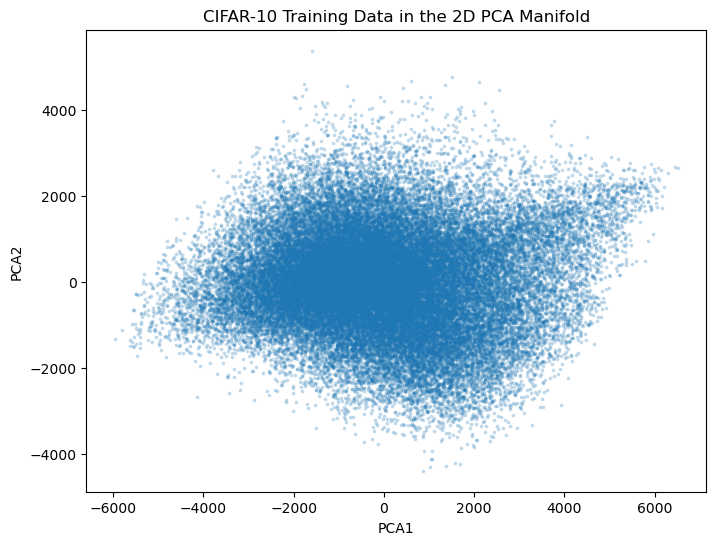

In [13]:

# Fit the 2D PCA manifold on the training partition, then transform separately.
pca2 = PCA(n_components = 2, svd_solver = 'full')
pca2.fit(xs_train)
train_pca2 = pca2.transform(xs_train)
print('Explained variance ratio:', pca2.explained_variance_ratio_)
print('Total variance explained by PCA1 + PCA2:', np.sum(pca2.explained_variance_ratio_))

# Show the 2 principal components as scatter-plot.
fig, ax = plt.subplots(figsize = (8, 6))
ax.scatter(train_pca2[:, 0], train_pca2[:, 1], s = 3, alpha = 0.20)
ax.set_title('CIFAR-10 Training Data in the 2D PCA Manifold')
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
plt.show()


In [14]:

# Use a subset to get a numeric sense of how many clusters this manifold supports.
rng = np.random.default_rng(328)
cluster_subset = rng.choice(len(train_pca2), size = 10000, replace = False)
cluster_rows = []
for k in range(2, 11):
    km = KMeans(init = 'k-means++', n_clusters = k, n_init = 4, random_state = 328)
    labels = km.fit_predict(train_pca2[cluster_subset])
    cluster_rows.append({
        'k': k,
        'silhouette': silhouette_score(train_pca2[cluster_subset], labels),
        'inertia': km.inertia_
    })
cluster_df = pd.DataFrame(cluster_rows)
cluster_df


,k,silhouette,inertia
0,2,0.398311,2.651783e+10
1,3,0.336668,1.995216e+10
2,4,0.351388,1.462825e+10
3,5,0.325844,1.224360e+10
4,6,0.336497,1.018463e+10
5,7,0.328273,8.986724e+09
6,8,0.324695,7.919768e+09
7,9,0.330288,7.025479e+09
8,10,0.327553,6.473484e+09


PC1 abs min / mean / max: 0.0015984438 0.016293507 0.028784925
PC2 abs min / mean / max: 0.0007490958 0.015670834 0.031198114
PC1 weak locations (<10% of max abs loading): 24 out of 1024
PC2 weak locations (<10% of max abs loading): 112 out of 1024


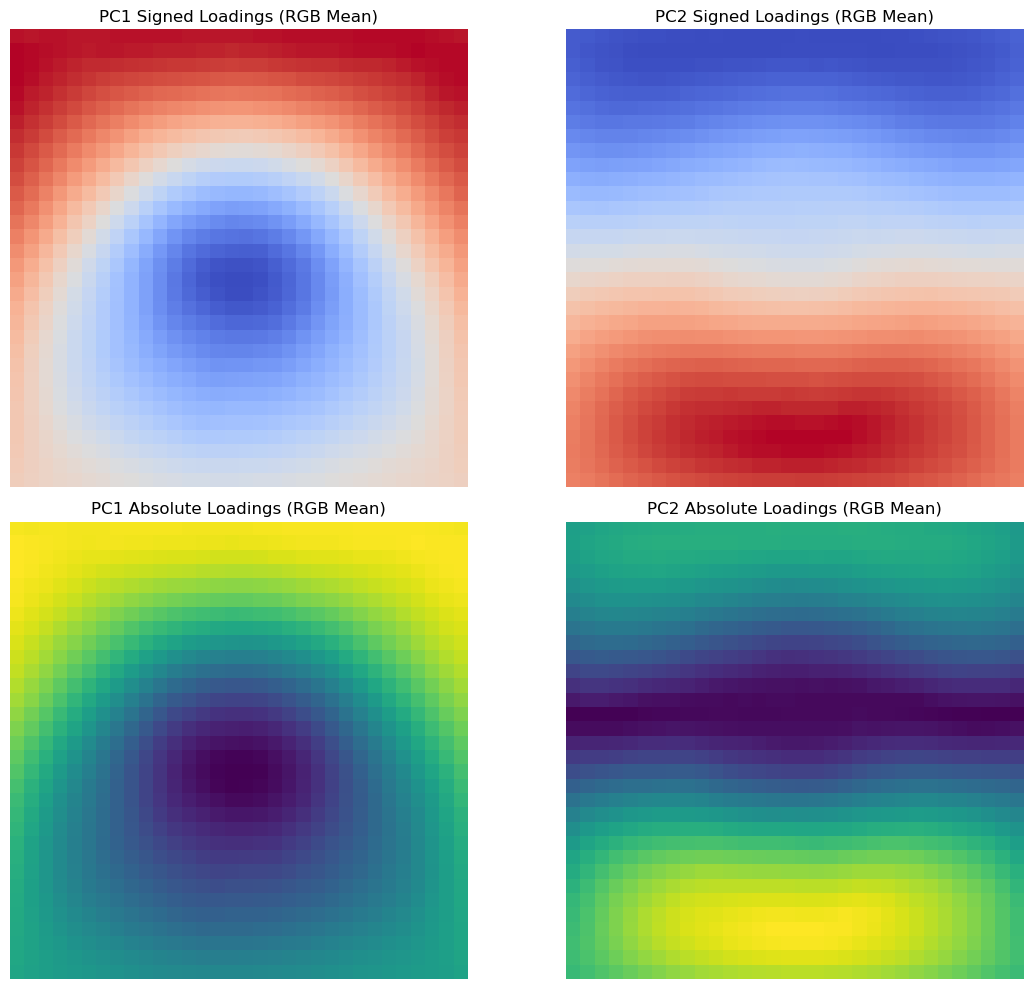

In [15]:

# Inspect the PCA coefficients to see how much each feature influences.
pca1 = pca2.components_[0].T.reshape((32, 32, 3))
pca2_coef = pca2.components_[1].T.reshape((32, 32, 3))

# For CIFAR-10, average across RGB channels to summarize each pixel location.
pca1_signed = np.mean(pca1, axis = 2)
pca2_signed = np.mean(pca2_coef, axis = 2)
pca1_abs = np.mean(np.abs(pca1), axis = 2)
pca2_abs = np.mean(np.abs(pca2_coef), axis = 2)
pc1_weak_count = int(np.sum(pca1_abs < 0.10 * pca1_abs.max()))
pc2_weak_count = int(np.sum(pca2_abs < 0.10 * pca2_abs.max()))
print('PC1 abs min / mean / max:', pca1_abs.min(), pca1_abs.mean(), pca1_abs.max())
print('PC2 abs min / mean / max:', pca2_abs.min(), pca2_abs.mean(), pca2_abs.max())
print('PC1 weak locations (<10% of max abs loading):', pc1_weak_count, 'out of', pca1_abs.size)
print('PC2 weak locations (<10% of max abs loading):', pc2_weak_count, 'out of', pca2_abs.size)

# Visualize which graphical regions (pixels) are "important" and not.
fig, axs = plt.subplots(2, 2, figsize = (12, 10))
axs[0, 0].imshow(pca1_signed, cmap = 'coolwarm')
axs[0, 0].set_title('PC1 Signed Loadings (RGB Mean)')
axs[0, 0].axis('off')
axs[0, 1].imshow(pca2_signed, cmap = 'coolwarm')
axs[0, 1].set_title('PC2 Signed Loadings (RGB Mean)')
axs[0, 1].axis('off')
axs[1, 0].imshow(pca1_abs, cmap = 'viridis')
axs[1, 0].set_title('PC1 Absolute Loadings (RGB Mean)')
axs[1, 0].axis('off')
axs[1, 1].imshow(pca2_abs, cmap = 'viridis')
axs[1, 1].set_title('PC2 Absolute Loadings (RGB Mean)')
axs[1, 1].axis('off')
plt.tight_layout()
plt.show()



1. Answer: 

- (a) After flattening the CIFAR-10 training images to 3072 predictors each, I fit the PCA model with `pca2.fit(xs_train)` and then transformed the training data separately with `pca2.transform(xs_train)`. The first two principal components explained `0.2907621` and `0.1125318` of the variance, so together the 2D manifold explained `0.4032940` or about 40.33% of the total variation. Not bad, but significantly worse than our class example on digits (or some other "nicer" datasets where the first 2 PCs can explain like 80% of the total variance).

- (b) There is definitely some visible structure in the manifold, but it is not a clean 10-cluster picture. The cloud has broad lobes and overlap rather than ten isolated groups. On a 10,000-point subset, the silhouette scores for `k=2` through `k=10` were `0.3983, 0.3367, 0.3514, 0.3258, 0.3365, 0.3283, 0.3247, 0.3303, 0.3276`, respectively, so the strongest numeric support is actually for `k=2`. If I had to predict the number of clusters without using the `Y` values, I would say there are about 2 dominant macro-clusters, with weaker sub-structure inside them, but definitely not 10 well-separated clusters. I'm sure if we were to visualize the clusters, it would show a lot of overlaps as we saw in some of our class examples with the MNIST digits data.

- (c) The PCA loading plots also look very different from MNIST. For PC1, only `24` of the `1024` pixel locations had an average absolute loading below 10% of the maximum absolute loading; for PC2, that count was `112` of `1024`. That means most of the image grid is contributing some information. In MNIST, there were obvious background regions with coefficients near 0 because most digits live in the center and the border is usually blank as we discussed in class and saw visually. Here, CIFAR-10 is made of natural color images, so useful variation is spread across much more of the frame.

- (d) This says CIFAR-10 carries richer but more diffuse information than MNIST. That helps explain two things at once: first, CIFAR-10 does not have large dead background zones like MNIST; second, prediction is harder because the important information is spread across the entire image and the classes overlap much more in low-dimensional views. So CIFAR-10 has more distributed information, but also stronger limits on simple low-dimensional separation.



2. Question:
- (a) How many PCA components are needed to explain 90% or more of the variance of CIFAR-10 data in the training partition?
- (b) Using the previously fit model in [1] use that manifold to transform the unseen data from the test data partition. Does the structure change significantly or are you seeing a similar pattern?


In [16]:

# Find how many PCA components are needed for 90% variance.
pca90 = PCA(n_components = 0.90)
pca90.fit(xs_train)
print('Number of PCA components for at least 90% variance:', pca90.n_components_)
print('Total variance explained by those components:', np.sum(pca90.explained_variance_ratio_))

# Reuse the previously fit 2D manifold on unseen test data.
test_pca2 = pca2.transform(xs_test)
comparison_df = pd.DataFrame({
    'set': ['train', 'test'],
    'PC1 mean': [train_pca2[:, 0].mean(), test_pca2[:, 0].mean()],
    'PC1 std': [train_pca2[:, 0].std(), test_pca2[:, 0].std()],
    'PC2 mean': [train_pca2[:, 1].mean(), test_pca2[:, 1].mean()],
    'PC2 std': [train_pca2[:, 1].std(), test_pca2[:, 1].std()]
})
comparison_df


Number of PCA components for at least 90% variance: 99
Total variance explained by those components: 0.90031797


,set,PC1 mean,PC1 std,PC2 mean,PC2 std
0,train,-0.002414,1897.346924,0.002003,1180.353027
1,test,47.309116,1896.552124,0.681806,1159.168091


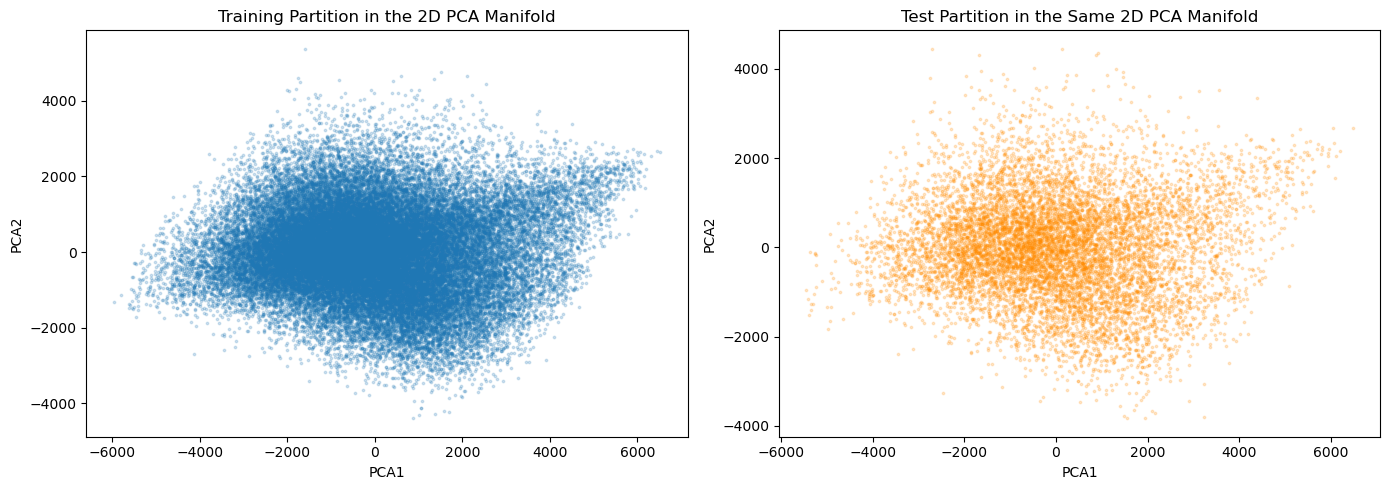

In [17]:

# Compare PC1 and PC2 in both training and testing sets.
fig, axs = plt.subplots(1, 2, figsize = (14, 5))
axs[0].scatter(train_pca2[:, 0], train_pca2[:, 1], s = 3, alpha = 0.20)
axs[0].set_title('Training Partition in the 2D PCA Manifold')
axs[0].set_xlabel('PCA1')
axs[0].set_ylabel('PCA2')
axs[1].scatter(test_pca2[:, 0], test_pca2[:, 1], s = 3, alpha = 0.20, color = 'darkorange')
axs[1].set_title('Test Partition in the Same 2D PCA Manifold')
axs[1].set_xlabel('PCA1')
axs[1].set_ylabel('PCA2')
plt.tight_layout()
plt.show()



2. Answer:
- (a) To explain at least 90% of the training variance, CIFAR-10 needed `99` principal components, which together explained `0.9003180` of the variance. That is another sign that CIFAR-10 is much more complex than MNIST: a 2D manifold is useful for visualization, but it is far from enough to retain most of the information.
- (b) When I transformed the unseen test partition with the same 2D PCA model from Question 1, the structure looked very similar to the training manifold rather than fundamentally different. Numerically, the training means were approximately `(-0.0024, 0.0020)` and the test means were `(47.3091, 0.6818)`, while the standard deviations stayed close: training `(1897.3469, 1180.3530)` versus test `(1896.5521, 1159.1681)`. When we visualize it, the test cloud sits in nearly the same shape and scale, which suggests the PCA structure generalizes reasonably well, even though the classes are still heavily overlapped.



3. Question: 
- (a) Take 2000 samples from the test partition using a random index selection and keep track of these indices in a list for step (c) and concatenate these test samples with the training `X, Y` partitions making sure to clear the `Y` labels from training (these you set to `-1` like in the scikit example). Let us call this the SSL-dataset. This means you have 2000 labeled images (0 to 9 class labels) and then you have 50000 labels that are missing (with a `-1` value). Once they are combined you need to shuffle them to make sure the model fit will not see all `-1`, etc.
- (b) Check you work by using statistical analysis (the total count of `-1`s should be 50000, the total number you see each of the other labels 0-9 should be about equal).
- (c) Now use the label propagation method to estimate the `-1` labels in the SSL-dataset (i.e., you can use the `fit` method).
- (d) For the 8000 samples you did not randomly select in part (a) use your model to predict the `Y` value and then check the accuracy (how often is it correct). How did it do?


In [18]:

# Use the 90%-variance PCA representation as the reusable manifold basis for SSL.
train_pca90 = pca90.transform(xs_train)
test_pca90  = pca90.transform(xs_test)

# Check a few PCA dimensions and keep the strongest one for label propagation.
ssl_rng = np.random.default_rng(328)
selected_test_indices = np.sort(ssl_rng.choice(len(xs_test), size = 2000, replace = False))
held_out_indices = np.setdiff1d(np.arange(len(xs_test)), selected_test_indices)
ssl_dim_rows = []
for dims in [2, 5, 10, 20, 30, 50, 75, 99]:
    ssl_X = np.vstack([train_pca90[:, :dims], test_pca90[selected_test_indices, :dims]])
    ssl_y = np.concatenate([np.full(len(xs_train), -1, dtype = int), y_test[selected_test_indices]])
    ssl_perm = np.random.default_rng(328).permutation(len(ssl_X))
    ssl_X = ssl_X[ssl_perm]
    ssl_y = ssl_y[ssl_perm]
    lp_try = LabelSpreading(kernel = 'knn', n_neighbors = 5, max_iter = 100)
    lp_try.fit(ssl_X, ssl_y)
    held_out_pred = lp_try.predict(test_pca90[held_out_indices, :dims])
    ssl_dim_rows.append({
        'dims': dims,
        'held_out_accuracy': accuracy_score(y_test[held_out_indices], held_out_pred),
        'n_iter': lp_try.n_iter_
    })
ssl_dim_df = pd.DataFrame(ssl_dim_rows)
ssl_dim_df


/Users/rsai_91/anaconda3/envs/COM328/lib/python3.14/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/Users/rsai_91/anaconda3/envs/COM328/lib/python3.14/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/Users/rsai_91/anaconda3/envs/COM328/lib/python3.14/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/Users/rsai_91/anaconda3/envs/COM328/lib/python3.14/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/Users/rsai_91/anaconda3/envs/COM328/lib/python3.14/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


,dims,held_out_accuracy,n_iter
0,2,0.138750,8
1,5,0.194000,9
2,10,0.228750,9
3,20,0.237625,9
4,30,0.235750,9
5,50,0.221250,9
6,75,0.225875,9
7,99,0.223500,9


In [19]:

# With the first 20 PCA coordinates performing best above, tune n_neighbors on that manifold.
neighbor_rows = []
for n_neighbors in [3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 30, 40, 50]:
    ssl_X = np.vstack([train_pca90[:, :20], test_pca90[selected_test_indices, :20]])
    ssl_y = np.concatenate([np.full(len(xs_train), -1, dtype = int), y_test[selected_test_indices]])
    ssl_perm = np.random.default_rng(328).permutation(len(ssl_X))
    ssl_X = ssl_X[ssl_perm]
    ssl_y = ssl_y[ssl_perm]
    lp_try = LabelSpreading(kernel = 'knn', n_neighbors = n_neighbors, max_iter = 100)
    lp_try.fit(ssl_X, ssl_y)
    held_out_pred = lp_try.predict(test_pca90[held_out_indices, :20])
    neighbor_rows.append({
        'n_neighbors': n_neighbors,
        'held_out_accuracy': accuracy_score(y_test[held_out_indices], held_out_pred),
        'n_iter': lp_try.n_iter_
    })
neighbor_df = pd.DataFrame(neighbor_rows)
neighbor_df


/Users/rsai_91/anaconda3/envs/COM328/lib/python3.14/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/Users/rsai_91/anaconda3/envs/COM328/lib/python3.14/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/Users/rsai_91/anaconda3/envs/COM328/lib/python3.14/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


,n_neighbors,held_out_accuracy,n_iter
0,3,0.195000,9
1,4,0.211750,9
2,5,0.237625,9
3,6,0.246625,9
4,7,0.249750,9
5,8,0.255750,9
6,10,0.259125,9
7,12,0.263750,9
8,15,0.271750,9
9,20,0.278750,9


In [20]:
# Build the final SSL dataset and fit the label spreading model.
ssl_X = np.vstack([train_pca90[:, :20], test_pca90[selected_test_indices, :20]])
ssl_y = np.concatenate([np.full(len(xs_train), -1, dtype = int), y_test[selected_test_indices]])
ssl_perm = np.random.default_rng(328).permutation(len(ssl_X))
ssl_X = ssl_X[ssl_perm]
ssl_y = ssl_y[ssl_perm]
ssl_counts = pd.Series(ssl_y).value_counts().sort_index()
print('First 30 selected test indices:', selected_test_indices[:30].tolist())
print('Number of selected test indices:', len(selected_test_indices))
print('Number of held-out test indices:', len(held_out_indices))
print('\nSSL label counts after shuffling:')
print(ssl_counts)
lp_model = LabelSpreading(kernel = 'knn', n_neighbors = 50, max_iter = 100)
lp_model.fit(ssl_X, ssl_y)
held_out_pred = lp_model.predict(test_pca90[held_out_indices, :20])
held_out_accuracy = accuracy_score(y_test[held_out_indices], held_out_pred)
report_df = pd.DataFrame(classification_report(
    y_test[held_out_indices], held_out_pred, output_dict = True, zero_division = 0
)).T
print('\nHeld-out exact accuracy:', held_out_accuracy)
print('Iterations used by label spreading:', lp_model.n_iter_)
report_df

First 30 selected test indices: [0, 6, 26, 31, 39, 49, 52, 55, 58, 63, 71, 75, 81, 89, 95, 98, 111, 112, 118, 123, 127, 128, 130, 137, 139, 150, 158, 161, 165, 168]
Number of selected test indices: 2000
Number of held-out test indices: 8000

SSL label counts after shuffling:
-1    50000
 0      183
 1      213
 2      204
 3      203
 4      201
 5      178
 6      210
 7      201
 8      202
 9      205
Name: count, dtype: int64

Held-out exact accuracy: 0.2915
Iterations used by label spreading: 8


,precision,recall,f1-score,support
0,0.369143,0.395349,0.381797,817.0000
1,0.487805,0.152478,0.232333,787.0000
2,0.193312,0.232412,0.211067,796.0000
3,0.237288,0.105395,0.145960,797.0000
4,0.201172,0.386733,0.264668,799.0000
5,0.394619,0.107056,0.168421,822.0000
6,0.200328,0.463291,0.279710,790.0000
7,0.457143,0.200250,0.278503,799.0000
8,0.405501,0.572682,0.474805,798.0000
9,0.475248,0.301887,0.369231,795.0000


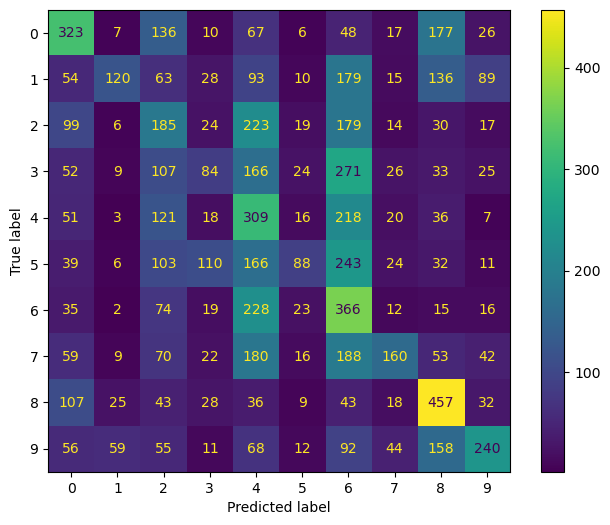

In [21]:

# Visualize confusion matrix to check for recall, precision, and accuracy.
ConfusionMatrixDisplay.from_predictions(
    y_test[held_out_indices], held_out_pred
)
plt.show()


3. Answer:
- (a) I took `2000` random test images with a fixed seed of `328` (just our class code), stored their indices in `selected_test_indices`, and used the remaining `8000` test images for evaluation. To keep the semisupervised step within the same class toolkit, I stayed with `sklearn` and used the PCA manifold as the feature space for graph propagation. I checked several PCA sizes using the reusable `pca90` basis from Question 2, and the best held-out accuracy among `2, 5, 10, 20, 30, 50, 75, 99` dimensions occurred at `20` dimensions. I then tuned `n_neighbors` on those first 20 PCs, and the best result in my sweep occurred at `n_neighbors = 50`.
- (b) The statistical check worked correctly. After concatenating the unlabeled training set with the 2000 labeled test images and then shuffling, the count of `-1` labels was exactly `50000`. The labeled counts were reasonably balanced across the ten classes: class `0: 183`, `1: 213`, `2: 204`, `3: 203`, `4: 201`, `5: 178`, `6: 210`, `7: 201`, `8: 202`, and `9: 205`.
- (c) Using `LabelSpreading(kernel='knn', n_neighbors=50, max_iter=100)` on the first 20 PCA coordinates, the model achieved held-out exact accuracy `0.2915` on the remaining `8000` test images. The macro precision was `0.3422`, the macro recall was `0.2918`, and the macro F1 score was `0.2806`. The strongest recalls were for class `8` (`0.5727`), class `6` (`0.4633`), class `4` (`0.3867`), class `0` (`0.3953`), and class `9` (`0.3019`), while the weakest were class `3` (`0.1054`), class `5` (`0.1071`), and class `1` (`0.1525`). So it did better than random guessing on a 10-class problem, but it is still a weak classifier overall. That is consistent with the earlier PCA results: CIFAR-10 has overlapping classes and a lot of distributed variation, so semisupervised graph propagation on a compact manifold helps somewhat, but not nearly enough to separate all ten classes cleanly.